**Question (9 Marks)**

A dataset named **`spx.csv`** contains stock market data with a column called **Close**. Some entries in the column may contain missing values represented by the symbol **`?`**.

Write a Python program to perform **Polynomial Regression** on the dataset and carry out the following tasks:

a) Read the dataset using Pandas. *(1 mark)*

b) Handle the missing values present in the **Close** column and convert the column to a suitable numeric datatype. *(1 mark)*

c) Create a new column named **Row_Number** containing sequential integers starting from 1 and use it as the independent variable. *(1 mark)*

d) Split the dataset into **training and testing sets** using an appropriate train–test split method keeping 20% of data for testing and random state of 42. *(1 mark)*

e) Train polynomial regression models for degrees **1 to 10** using the training data. *(2 marks)*

f) Compute **R² Score** and **Mean Squared Error (MSE)** for each degree using the test data and determine the **best polynomial degree and print it**. *(1 mark)*

g) Plot the following graphs: *(1 mark)*

* Scatter plot showing **actual vs predicted values**
* Graph showing **polynomial degree vs R² score and MSE**

h) Using the selected polynomial model, **predict the next five values of the Close column**. *(1 mark)*

**OUTPUT FOR REFERENCE**
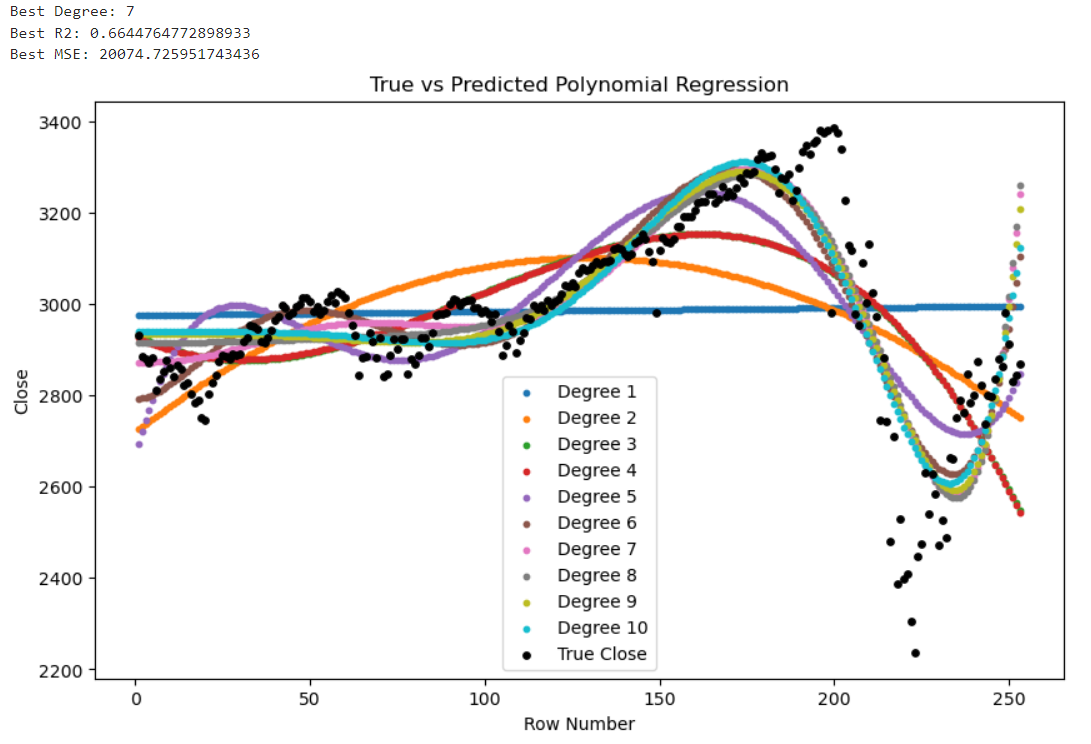
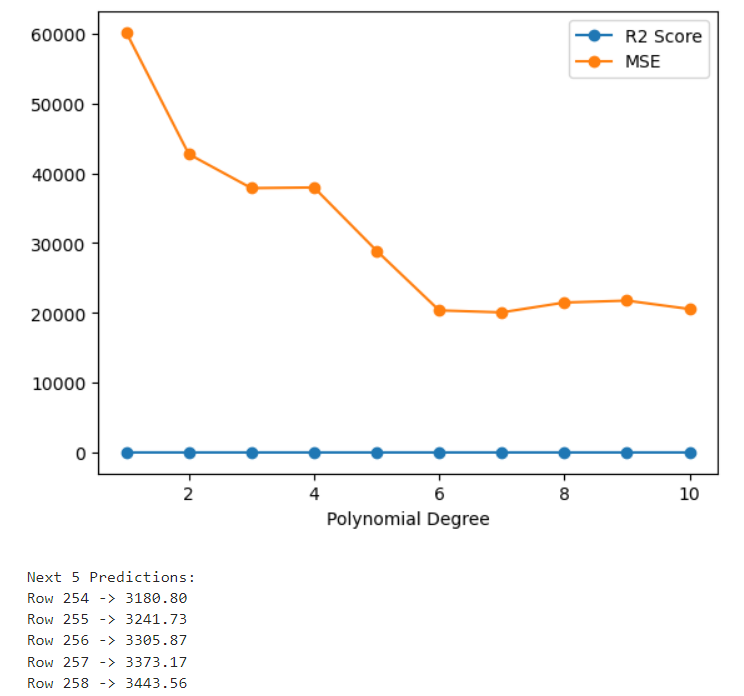

__.__
<!-- 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("spx.csv")

# Handle missing values
df["Close"] = df["Close"].replace("?", np.nan).astype(float)
df["Close"] = df["Close"].fillna(df["Close"].mean())

# Add Row_Number column
df["Row_Number"] = np.arange(1, len(df)+1)

X = df[["Row_Number"]].values
y = df["Close"].values

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

degrees = range(1,11)

r2_scores = []
mses = []
models = []
polys = []

for d in degrees:

    poly = PolynomialFeatures(degree=d)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    r2_scores.append(r2_score(y_test, y_pred))
    mses.append(mean_squared_error(y_test, y_pred))

    models.append(model)
    polys.append(poly)

# Find best degree (without argmax)
best_r2 = -1
best_degree = None
best_index = 0

for i in range(len(r2_scores)):

    if r2_scores[i] > best_r2:
        best_r2 = r2_scores[i]
        best_degree = degrees[i]
        best_index = i

print("Best Degree:", best_degree)
print("Best R2:", r2_scores[best_index])
print("Best MSE:", mses[best_index])

# -------------------------
# Scatter plot True vs Predicted
# -------------------------

plt.figure(figsize=(10,6))

for i, d in enumerate(degrees):

    poly = polys[i]
    model = models[i]

    X_poly = poly.transform(X)
    y_pred = model.predict(X_poly)

    plt.scatter(X, y_pred, s=10, label=f"Degree {d}")

plt.scatter(X, y, color="black", s=15, label="True Close")

plt.xlabel("Row Number")
plt.ylabel("Close")
plt.title("True vs Predicted Polynomial Regression")

plt.legend()
plt.show()


# R2 vs MSE Plot
plt.plot(degrees, r2_scores, marker='o', label="R2 Score")
plt.plot(degrees, mses, marker='o', label="MSE")
plt.xlabel("Polynomial Degree")
plt.legend()
plt.show()

# Predict next 5 values
future_rows = np.arange(len(df)+1, len(df)+6).reshape(-1,1)
future_poly = poly.transform(future_rows)
future_pred = model.predict(future_poly)

print("\nNext 5 Predictions:")
for i,v in enumerate(future_pred):
    print(f"Row {future_rows[i][0]} -> {v:.2f}") 
    
 -->